In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt



In [65]:
# Leitura dos dados de treino
df_train = pd.read_csv('../data/train.csv')

# Dados das primeiras 5 linhas do dataset
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [66]:
# Verificação do tipo de dados e valores nulos
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
# Contagem dos sobreviventes (1) e não sobreviventes (0)
print(df_train['Survived'].value_counts())

# Percentagem de sobreviventes e não sobreviventes
print("\nPercentagem:")

taxa_sobrevivencia = df_train['Survived'].value_counts(normalize=True)

# Mostra os valores em percentagem formatados com 1 casa decimal e o símbolo %
print(f"Sobreviveram:     {taxa_sobrevivencia[1]:.1%}")
print(f"Não Sobreviveram: {taxa_sobrevivencia[0]:.1%}")


Survived
0    549
1    342
Name: count, dtype: int64

Percentagem:
Sobreviveram:     38.4%
Não Sobreviveram: 61.6%


In [68]:
# Taxa de sobrevivência por género
tabela_sexo = pd.crosstab(df_train['Sex'], df_train['Survived'], normalize='index')
tabela_sexo.columns = ['Não Sobreviveu', 'Sobreviveu']
tabela_sexo.style.format("{:.1%}")


,Não Sobreviveu,Sobreviveu
Sex,,
female,25.8%,74.2%
male,81.1%,18.9%


In [69]:
# Taxa de sobrevivência por classe social
tabela_classe = pd.crosstab(df_train['Pclass'], df_train['Survived'], normalize='index')
tabela_classe.columns = ['Não Sobreviveu', 'Sobreviveu']
tabela_classe.style.format("{:.1%}")

,Não Sobreviveu,Sobreviveu
Pclass,,
1,37.0%,63.0%
2,52.7%,47.3%
3,75.8%,24.2%


In [70]:
# Taxa de sobrevivência por classe e género
tabela_mista = pd.crosstab([df_train['Pclass'], df_train['Sex']], df_train['Survived'], normalize='index')
tabela_mista.columns = ['Não Sobreviveu', 'Sobreviveu']
tabela_mista.style.format("{:.1%}")

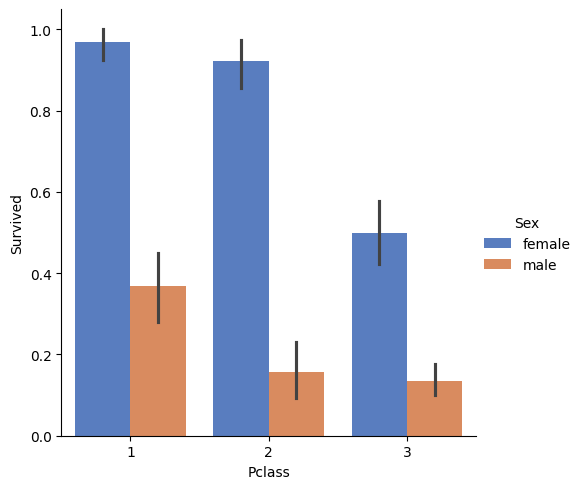

In [71]:
# Gráfico de sobrevivência por classe e género
sns.catplot(data=df_train, x='Pclass', y='Survived', hue='Sex', kind='bar', palette='muted')

<Axes: xlabel='Age', ylabel='Count'>

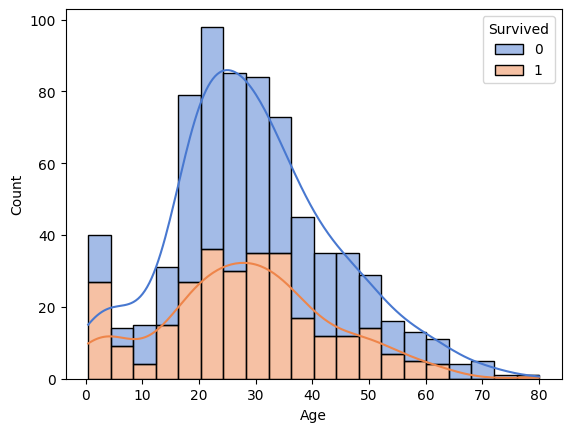

In [72]:
# Distribuição da idade por sobrevivência
sns.histplot(data=df_train, x='Age', hue='Survived', multiple='stack', kde=True, palette='muted')

## Conclusões da Análise Exploratória (EDA)

Com base nos dados analisados, identificámos três padrões claros que guiarão a criação do modelo preditivo:
1. **O fator género:** As mulheres tiveram uma taxa de sobrevivência drasticamente superior (~74% vs ~19%).
2. **O fator socioeconómico:** Os passageiros da 1ª classe tiveram forte prioridade sobre os da 3ª classe (~63% vs ~24%).
3. **O fator idade:** Crianças pequenas (0-5 anos) tiveram maior probabilidade de sobrevivência.

---

## Limpeza e Preparação de Dados

Antes de treinar o modelo, precisamos de tratar os dados em falta identificados no início (`Age`, `Cabin`, `Embarked`). 
O nosso primeiro foco será a **Idade**, investigando se a classe social pode ajudar a preencher os valores nulos de forma mais inteligente.

In [73]:
# Mediana da idade por classe social
df_train.groupby('Pclass')['Age'].median()

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

Como podemos observar pelos resultados, se utilizarmos a mediana geral iríamos envelhecer artificialmente as pessoas da 3ª classe e rejuvenescer os passageiros da 1ª classe. Para evitar que isto aconteça, a melhor abordagem é usar a mediana de cada classe.

In [74]:
# Preenche os valores nulos da idade com a mediana da respetiva classe
df_train['Age'] = df_train['Age'].fillna(df_train.groupby('Pclass')['Age'].transform('median'))

# Verifica se ainda restam valores nulos na Idade
print(f"Valores nulos na coluna Age: {df_train['Age'].isnull().sum()}")

Valores nulos na coluna Age: 0


Como vimos anteriormente, a coluna Embarked tem apenas dois valores em falta. Sendo uma variável categórica (texto), não faz sentido utilizar médias ou medianas. A abordagem padrão neste tipo de cenário é usar a moda, preenchendo os valores vazios com o porto de embarque mais frequente.

In [75]:
# Conta a frequência de cada porto de embarque
df_train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [ ]:
# Preencher os 2 valores em falta com o porto mais frequente ('S')
df_train['Embarked'] = df_train['Embarked'].fillna('S')

# Verifica se ainda restam valores nulos na coluna Embarked
print(f"Valores nulos na coluna Embarked: {df_train['Embarked'].isnull().sum()}")

Valores nulos na coluna Embarked: 0


A coluna Cabin apresenta um cenário crítico: tem 687 linhas com valores nulos, o que representa cerca de 77% de dados em falta. Como não é possível preenchê-los de forma estruturada e lógica, a abordagem mais indicada é remover a coluna do dataset.

In [ ]:
# Remover a coluna 'Cabin' do dataset
df_train = df_train.drop(columns=['Cabin'])

# Verificar o formato atual do dataset (linhas, colunas)
print(f"Novo formato do dataset: {df_train.shape}")

Novo formato do dataset: (891, 11)


In [78]:
# Validação final: todas as colunas devem dar 0 nulos
df_train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Variáveis Categóricas
Os modelos de Machine Learning não conseguem processar texto diretamente, pelo que precisamos de converter as variáveis categóricas em números. Vamos começar por transformar a coluna Sex num formato binário, onde as mulheres serão representadas por 1 e os homens por 0.

In [ ]:
# Converter a coluna 'Sex' em valores numéricos (0 e 1)
df_train['Sex'] = df_train['Sex'].map({'female': 1, 'male': 0})

# Visualizar as primeiras linhas para confirmar a alteração
df_train[['Name', 'Sex']].head()

,Name,Sex
0,"Braund, Mr. Owen Harris",0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1
2,"Heikkinen, Miss. Laina",1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
4,"Allen, Mr. William Henry",0


Para a coluna Embarked, que possui três categorias ('S', 'C' e 'Q'), não podemos simplesmente atribuir números sequenciais (0, 1, 2). Se o fizermos, o modelo de Machine Learning tentará criar uma relação de ordem artificial, assumindo incorretamente que um porto "vale mais" do que outro.

Para evitar isto, utilizamos a técnica One-Hot Encoding. Esta abordagem remove a coluna original e cria três novas colunas binárias (uma para cada porto), atribuindo o valor 1 se o passageiro embarcou nesse porto e 0 caso contrário.

In [80]:
# One-Hot Encoding na coluna Embarked
df_train = pd.get_dummies(df_train, columns=['Embarked'], dtype=int)

# Visualizar as novas colunas criadas no fim do dataset
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,0,1


In [ ]:
# Mostrar o tipo de dados de todas as colunas atuais
df_train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked_C       int64
Embarked_Q       int64
Embarked_S       int64
dtype: object

Antes de iniciar a criação dos modelos de Machine Learning, precisamos de garantir que o dataset contém apenas dados numéricos e úteis. As colunas Name e Ticket, além de estarem em formato de texto, contêm demasiada informação específica que não traz qualquer poder preditivo ao algoritmo, funcionando apenas como ruído.

Da mesma forma, a coluna PassengerId funciona apenas como um identificador ou contador de linhas — algo que o próprio índice do DataFrame já faz de forma nativa. Por isso, a melhor abordagem é excluir estas três colunas da nossa matriz de características.

Com o dataset devidamente limpo e codificado, o passo seguinte consiste em isolar as variáveis de interesse. Criámos a matriz de características ($X$), excluindo as colunas PassengerId, Name e Ticket, bem como a variável alvo Survived. Esta última foi isolada no vetor de respostas ($y$).

In [82]:
# Separação do dataset em features (X) e target (y) e eliminação das colunas irrelevantes

# X recebe as características (Features), descartando o alvo e as colunas irrelevantes
X = df_train.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket'])

# y recebe apenas a coluna alvo (Target)
y = df_train['Survived']

# Confirmar o formato final de X e y
print(f"Formato de X (Features): {X.shape}")
print(f"Formato de y (Target): {y.shape}")

Formato de X (Features): (891, 9)
Formato de y (Target): (891,)


## Treino do Primeiro Modelo de Machine Learning
Com os dados estruturados em $X$ e $y$, avançamos para o treino do nosso primeiro modelo preditivo. Para esta abordagem inicial, optámos por uma Árvore de Decisão (Decision Tree) devido à sua natureza visual e facilidade de interpretação, servindo como a nossa baseline (modelo de referência).

In [83]:
# Criar o modelo (profundidade máxima de 3 para não complicar)
modelo_titanic = DecisionTreeClassifier(max_depth=3, random_state=42)

# Treinar o modelo com os nossos dados ("fit")
modelo_titanic.fit(X, y)

print("Modelo treinado com sucesso! 🚀")

Modelo treinado com sucesso! 🚀


In [84]:
# Avaliar a precisão (accuracy) do modelo exemplo de overfitting
precisao = modelo_titanic.score(X, y)

print(f"Precisão do modelo: {precisao * 100:.2f}%")

Precisão do modelo: 82.72%


O modelo atingiu uma precisão inicial de 82,72%. Embora seja um excelente ponto de partida, é crucial notar que esta métrica foi calculada utilizando os mesmos dados de treino. Para obtermos uma validação realista e prevenir o fenómeno de overfitting (onde o modelo apenas decora os dados em vez de aprender padrões gerais), o passo seguinte será realizar uma divisão entre dados de treino e dados de teste (Train/Test Split).

## Validação do Modelo com Divisão de Treino e Teste
Para obtermos uma avaliação realista do modelo e evitar o overfitting, vamos dividir os nossos dados ($X$ e $y$) em dois conjuntos distintos: 80% para treino (estudo) e 20% para teste (exame final com dados inéditos).

In [85]:
# 1. Dividir os dados (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Criar um novo modelo idêntico
modelo_real = DecisionTreeClassifier(max_depth=3, random_state=42)

# 3. Treinar o modelo APENAS com os dados de treino
modelo_real.fit(X_train, y_train)

# 4. Avaliar a precisão nos dados de teste
precisao_real = modelo_real.score(X_test, y_test)

print(f"Nova precisão real do modelo: {precisao_real * 100:.2f}%")

Nova precisão real do modelo: 79.89%


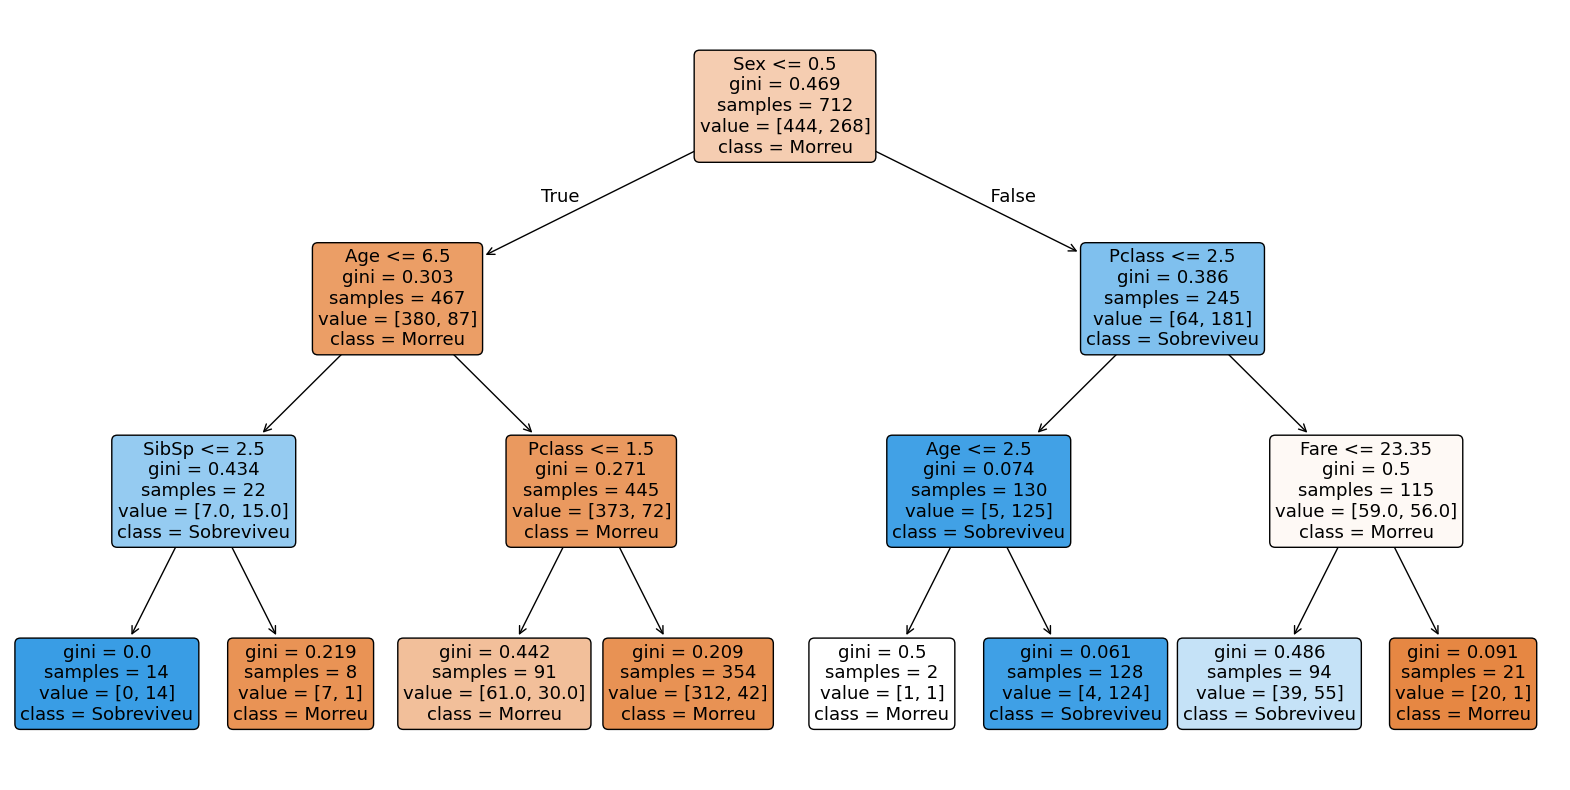

In [86]:
# Visualização da Árvore de Decisão

# Define o tamanho da imagem
plt.figure(figsize=(20,10))

# Desenha a árvore com os nomes das colunas
plot_tree(modelo_real, feature_names=X.columns.tolist(), class_names=['Morreu', 'Sobreviveu'], filled=True, rounded=True)

plt.show()

Visualização da Árvore de Decisão  

O gráfico acima demonstra as regras de decisão criadas pelo algoritmo. A divisão principal baseia-se no género (Sex), seguida pela idade (Age) para os homens e pela classe social (Pclass) para as mulheres, refletindo os padrões históricos de sobrevivência do desastre.

## Teste de Modelo Alternativo: Regressão Logística
Para comparar com a nossa árvore de decisão, vamos implementar uma Regressão Logística. Como este é um algoritmo linear, aplicamos uma etapa prévia de padronização dos dados (StandardScaler) para garantir que colunas com amplitudes numéricas maiores (como Fare ou Age) não distorçam os pesos do modelo.

In [87]:
# 1. Criar um Pipeline que primeiro escala os dados e depois aplica a Regressão Logística
modelo_logistica = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))

# 2. Treinar o modelo com os dados de treino
modelo_logistica.fit(X_train, y_train)

# 3. Avaliar a precisão real com os dados de teste
precisao_logistica = modelo_logistica.score(X_test, y_test)

print(f"Precisão da Regressão Logística: {precisao_logistica * 100:.2f}%")
print(f"Precisão Árvore de Decisão: {precisao_real * 100:.2f}%")

Precisão da Regressão Logística: 81.01%
Precisão Árvore de Decisão: 79.89%


## Teste de Modelo Avançado: Random Forest
Para tentar superar a marca de 81,01% estabelecida pela Regressão Logística, vamos implementar um Random Forest Classifier. Este algoritmo de ensemble combina múltiplas árvores de decisão independentes para criar um preditor mais robusto e menos propenso a overfitting.

In [88]:
# 1. Criar o modelo de Random Forest
modelo_floresta = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 2. Treinar o modelo
modelo_floresta.fit(X_train, y_train)

# 3. Avaliar a precisão nos dados de teste
precisao_floresta = modelo_floresta.score(X_test, y_test)

print(f"Precisão do Random Forest: {precisao_floresta * 100:.2f}%")
print(f"Precisão da Regressão Logística: {precisao_logistica * 100:.2f}%")

Precisão do Random Forest: 82.12%
Precisão da Regressão Logística: 81.01%


## Otimização de Hiperparâmetros com GridSearchCV
Com o Random Forest consolidado como o melhor modelo (82,12%), aplicamos o GridSearchCV para testar sistematicamente várias combinações de hiperparâmetros (como o número de árvores e a profundidade máxima). O objetivo é encontrar o ajuste fino ideal que maximize a capacidade de generalização do algoritmo.

In [89]:
# 1. Definir o "menu" de opções que queremos testar
parametros = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 4, 5, 6, 7],
    'criterion': ['gini', 'entropy']
}

# 2. Criar o GridSearchCV usando o nosso Random Forest
otimizador = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=parametros, cv=5, n_jobs=-1)

# 3. Testar todas as combinações nos dados de treino
otimizador.fit(X_train, y_train)

# 4. Descobrir quais foram os melhores parâmetros
print(f"Melhores parâmetros encontrados: {otimizador.best_params_}")

# 5. Avaliar a precisão real do MELHOR modelo nos dados de teste
melhor_modelo = otimizador.best_estimator_
precisao_tunada = melhor_modelo.score(X_test, y_test)

print(f"\nPrecisão do Random Forest: {precisao_floresta * 100:.2f}%")
print(f"Precisão do Random Forest Otimizado: {precisao_tunada * 100:.2f}%")

Melhores parâmetros encontrados: {'criterion': 'gini', 'max_depth': 5, 'n_estimators': 200}

Precisão do Random Forest: 82.12%
Precisão do Random Forest Otimizado: 81.56%


## Preparação do Dataset de Teste Oficial (Kaggle)
Para submetermos as previsões ao Kaggle, carregamos o ficheiro test.csv e aplicamos exatamente o mesmo pipeline de engenharia de recursos (feature engineering) utilizado nos dados de treino: preenchimento de valores nulos e codificação da variável de género (Sex).

In [90]:
# 1. Carregar o desafio oficial do Kaggle
dados_teste_Kaggle = pd.read_csv('../data/test.csv')

dados_teste_Kaggle.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [91]:
# Info dos dados de teste do Kaggle
dados_teste_Kaggle.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [92]:
# 2. Aplicar as MESMAS transformações feitas anteriormente
# Preencher idades em falta com a mediana
dados_teste_Kaggle['Age'] = dados_teste_Kaggle['Age'].fillna(
    dados_teste_Kaggle.groupby('Pclass')['Age'].transform('median'))

# Preencher tarifas em falta com a moda (o test.csv tem uma tarifa nula)
dados_teste_Kaggle['Fare'] = dados_teste_Kaggle['Fare'].fillna(dados_teste_Kaggle['Fare'].mode()[0])

# Mapear Sex para 0 e 1 (Homem = 0, Mulher = 1)
dados_teste_Kaggle['Sex'] = dados_teste_Kaggle['Sex'].map({'male': 0, 'female': 1})

# Transformar a coluna Embarked em colunas Dummy (0 e 1)
dados_teste_Kaggle = pd.get_dummies(dados_teste_Kaggle, columns=['Embarked'], dtype=int)

# 3. Guardar os IDs
passenger_ids = dados_teste_Kaggle['PassengerId']

# 4. Retirar as colunas irrelevantes
X_Kaggle = dados_teste_Kaggle.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# 5. Garantir que as colunas são EXATAMENTE as mesmas que no treino (mesma ordem)
X_Kaggle = X_Kaggle.reindex(columns=X.columns, fill_value=0)


In [93]:
# 4. Prever os resultados usando o melhor modelo encontrado no GridSearchCV
# (.predict gera as respostas 0 ou 1 para cada passageiro)
previsoes_finais = melhor_modelo.predict(X_Kaggle)

print("Previsões geradas com sucesso!")
print(f"Total de passageiros previstos: {len(previsoes_finais)}")
print(f"Primeiras 10 previsões (0=Morreu, 1=Sobreviveu): {previsoes_finais[:10]}")

Previsões geradas com sucesso!
Total de passageiros previstos: 418
Primeiras 10 previsões (0=Morreu, 1=Sobreviveu): [0 0 0 0 0 0 1 0 1 0]


In [ ]:
# 1. Criar um novo DataFrame com a estrutura exata que o Kaggle pede
submissao = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': previsoes_finais
}) 

# 2. Guardar o DataFrame como um ficheiro CSV
# index=False é OBRIGATÓRIO para o Pandas não criar uma coluna de números extra
submissao.to_csv('../data/submissao_titanic.csv', index=False)

print("Ficheiro 'submissao_titanic.csv' criado com sucesso na tua pasta!")
print("\nLook das primeiras linhas do ficheiro a enviar:")
print(submissao.head())

Ficheiro 'submissao_titanic.csv' criado com sucesso na tua pasta!

Look das primeiras linhas do ficheiro a enviar:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
